In [48]:
import sys
import os

sys.path.insert(0, os.path.abspath('..'))

from app.utils.gpt_parser import canonical_portfolio
import pandas as pd
import numpy as np
from datetime import datetime, timedelta
from app.core.calculations.returns.calculator import ReturnsCalculator, PortfolioReturnsCalculator
from app.core.calculations.performance.calculator import PerformanceCalculator
from app.core.calculations.risk.calculator import RiskCalculator
from app.repositories.price_data import get_price_data_daily, get_dividends_series
from app.repositories.price_data import fetch_bulk_price_data_for_tickers
import matplotlib.pyplot as plt
# Fetch industry and sub-industry data for all tickers
from app.db.core.db_config import MarketSession, ProphitAltsSession
from app.db.core.market_data_models import Ticker



In [49]:
x = {"portfolio": [{"ticker": "CAG", "position": "long", "thesis": "ConAgra Brands represents an undervalued, low-risk staple with visible margin inflection driven by pricing power and cost actions. Discounted valuation vs staples peers, sustainable FCF, and margin recovery position CAG for re-rating.", "key_drivers": "1) Margin Recovery: Cost and pricing actions; 2) Valuation Discount: EV/EBIT and FCF yield; 3) Low Leverage: Defensible balance sheet; 4) Limited Commodity Risk; 5) Technical reversal supports position.", "allocation": 0.08}, {"ticker": "CL", "position": "long", "thesis": "Colgate-Palmolive is a resilient franchise globally, with high ROIC, defensive product mix, strong innovation, and emerging market growth. Recent reset provides margin of safety; cash generation secures compounding.", "key_drivers": "1) Global brand strength; 2) Margin/ROIC leadership; 3) Emerging market expansion; 4) Recent underperformance; 5) Conservative capital allocation.", "allocation": 0.05}, {"ticker": "BJ", "position": "long", "thesis": "BJ\u2019s Wholesale Club is a best-in-class club/discounter, offering strong defensive traffic, private label growth, and digital/loyalty leverage versus peers; trades at discount to group with higher ROIC.", "key_drivers": "1) Private label and digital scaling; 2) Macro insulation; 3) Margin expansion; 4) Defensive discount peer group; 5) Loyalty investments drive results.", "allocation": 0.09}, {"ticker": "IPAR", "position": "long", "thesis": "Inter Parfums leverages a prestige-driven model, asset-light structure, and positive global consumer trends. Coach license extension, brand pipeline, and structural mix-shift support sustained margin and FCF upside.", "key_drivers": "1) Brand diversification; 2) Superior FCF generation; 3) Pricing and premiumization tailwind; 4) Asset-light resilience; 5) Positive earnings momentum.", "allocation": 0.11}, {"ticker": "EPC", "position": "long", "thesis": "Edgewell is a value contrarian benefiting from productivity/cost programs, A&P ROI, and category tailwinds. Improving brand momentum and tariffs manageable, with valuation still at a discount.", "key_drivers": "1) Productivity/cost tailwinds; 2) Brand cycle inflection; 3) Tariff management; 4) Recovery at trough multiples; 5) Insider/management alignment.", "allocation": 0.1}, {"ticker": "MO", "position": "long", "thesis": "Altria is a structurally cash-rich, high FCF yield business with defensive U.S. tobacco exposure, regulatory overhangs priced-in, and sustainable capital returns positioning for mean-reversion.", "key_drivers": "1) Defensive cash flows; 2) Regulatory timeline advantage; 3) Superior dividend yield; 4) Margin/OCF stability; 5) Depressed peer multiples.", "allocation": 0.12}, {"ticker": "KMB", "position": "long", "thesis": "Kimberly-Clark shows discounted valuation into GM/OCF normalization, strong FCF, and proven cost/innovation cycle. Underappreciated earnings leverage as pulp/input costs fade.", "key_drivers": "1) Margin expansion cycle; 2) Deep discount vs group; 3) Steady dividend support; 4) Cost/innovation upside; 5) Balance sheet flexibility.", "allocation": 0.06}, {"ticker": "BG", "position": "long", "thesis": "Bunge offers asymmetric commodity/food supply exposure, disciplined risk management, and asset-light origination. Share price at a discount to mid-cycle cash and ag peers.", "key_drivers": "1) Risk-managed cash flow; 2) Underowned/discounted; 3) Peer-relative value; 4) Traceability/regulatory tailwind; 5) Ag/commodities cycle leverage.", "allocation": 0.11}, {"ticker": "GIS", "position": "long", "thesis": "General Mills trades at modest valuation, offers mean-reversion potential in margins and SKUs. Defensive, FCF-rich staple with volume/SG&A initiatives putting a floor under estimates.", "key_drivers": "1) Margin mean-reversion catalyst; 2) Defensive staple; 3) Trade-spend/ROI cycle; 4) Valuation floor; 5) SKU/brand rationalization tailwind.", "allocation": 0.06}, {"ticker": "TGT", "position": "long", "thesis": "Target is a recovery story with inflecting traffic, private label advantages, and multi-channel scale undervalued after recent derating; margin and OCF inflection set up strong relative returns.", "key_drivers": "1) Margin/traffic inflection; 2) Private label/brand moat; 3) Digital omnichannel penetration; 4) Discounted EPS recovery; 5) Risk/return asymmetry.", "allocation": 0.11}, {"ticker": "INGR", "position": "long", "thesis": "Ingredion stands out through cost-plus model, specialty mix shift, and regulatory tailwinds favoring suppliers with traceable ingredients. Margins, ROIC, and FCF at peer-leading levels.", "key_drivers": "1) Specialty growth; 2) Cost-plus stability; 3) Traceability/regulatory advantage; 4) Modest peer multiples; 5) ROIC/FCF outperform.", "allocation": 0.11}, {"ticker": "CCEP", "position": "long", "thesis": "Coca-Cola Europacific Partners brings best-in-class pricing, shelf stability, and cash conversion as the dominant KO bottler. Shares offer global beverage exposure at relative discount, with resilient category/route economics.", "key_drivers": "1) Superior pricing power; 2) Distribution moat; 3) Consistent capital return; 4) SKU/facing optimization; 5) International low-volatility growth.", "allocation": 0.12}, {"ticker": "RLX", "position": "long", "thesis": "RLX is a contrarian deep value opportunity in China ENDS, with cash-rich balance sheet, high quick ratio, and below-global peer valuation. Analyst signals turning more positive as cash/earnings stabilize.", "key_drivers": "1) Deep value vs peers; 2) Balance sheet strength; 3) Cash/earnings stabilization catalysts; 4) Regulatory/catalyst optionality; 5) Small dividend reinstatement.", "allocation": 0.03}, {"ticker": "TAP", "position": "long", "thesis": "Molson Coors is a deep-value inflection, with cash/OCF turning higher on innovation and seasonal cycles. Shelf-space/distribution moat insulates share, while valuation remains too pessimistic for fundamentals.", "key_drivers": "1) Margins/OCF inflecting; 2) Sentiment/self-help improvement; 3) Route/shelf moats; 4) Innovation cycle; 5) FCF/valuation discount.", "allocation": 0.12}, {"ticker": "REYN", "position": "long", "thesis": "Reynolds Consumer is an FCF-rich, margin-repair story trading at a discount in household packaging. Cost/restructuring set up multi-quarter deleveraging and sentiment repair.", "key_drivers": "1) FCF margin leader; 2) Resin/cost stabilization; 3) Debt reduction track; 4) Sector discount; 5) Sentiment/tactical setup.", "allocation": 0.04}, {"ticker": "COST", "position": "long", "thesis": "Costco is an elite operator with defensible traffic, pricing advantage, world-class private label brands, and omnichannel upside. Margins and cash returns set BEST risk/reward among U.S. retail staples.", "key_drivers": "1) Elite ops/traffic; 2) Pricing power; 3) Private label runway; 4) Digital scaling; 5) Best-in-class risk/return in staples retail.", "allocation": 0.03}, {"ticker": "SAM", "position": "long", "thesis": "Boston Beer is inflecting from a trough supported by balance sheet strength, innovation cadence, and seasonality within beverages. Discounted group multiple bakes in excessive pessimism.", "key_drivers": "1) Earnings innovation cycle; 2) Underperformance setup; 3) Premiumization; 4) Balance sheet/FCF; 5) Defensiveness among beverage peers.", "allocation": 0.12}, {"ticker": "KVUE", "position": "long", "thesis": "Kenvue\u2019s consumer health platform delivers defensive FCF, margin, and steady cost levers. TSA exit and simplified business mix, plus strong channel/portfolio breadth, support an overlooked margin of safety.", "key_drivers": "1) Defensive FCF/cost base; 2) Portfolio simplification; 3) Breadth of branded channel; 4) Compliance/operational execution; 5) Regulatory/cost controls.", "allocation": 0.11}, {"ticker": "CELH", "position": "short", "thesis": "Celsius Holdings is priced for perfection with high multiples unsupported by recent growth normalization and shelf reset risk. Competition is intensifying, rating trends are cautious, and EV/EBITDA is extended far above peers.", "key_drivers": "1) Multiple/valuation risk; 2) Shelf/promotional resets; 3) Tactical rating downgrades; 4) Sensitivity to trend change and volatility; 5) Competitive pressure from larger beverages and private label.", "allocation": 0.047}, {"ticker": "CHD", "position": "short", "thesis": "Church & Dwight shows slowing growth, regulatory/reformulation cost risk, and a rich valuation versus household products group peers. Margins are under pressure from promo intensity and compliance.", "key_drivers": "1) Expansion cost/risk; 2) Rich peer valuation; 3) Margin pressure; 4) Elevated promo spend; 5) Regulatory cost uncertainty.", "allocation": 0.038}, {"ticker": "ELF", "position": "short", "thesis": "e.l.f. Beauty\u2019s valuation is stretched even after outperformance. Tariff and pricing actions hit margins, and integration risk from Rhode/China sourcing raises volatility.", "key_drivers": "1) Tariff/pricing risk; 2) China supply exposure; 3) Integration risk; 4) Rich EV/EBIT and momentum; 5) Weak relative setup for near-term.", "allocation": 0.046}, {"ticker": "FIZZ", "position": "short", "thesis": "National Beverage trades at a premium to beverage staples despite slowing top line and private label encroachment. Execution risk, limited scale, and lack of moat leave asymmetric downside.", "key_drivers": "1) Premium multiple; 2) Growth slowdown; 3) Promo intensity; 4) Scale limit; 5) Limited sector moat.", "allocation": 0.048}, {"ticker": "FRPT", "position": "short", "thesis": "Freshpet has a demanding valuation and thin profitability. The premium pet category is sensitive to trade-down and promotional action; sustained GM expansion faces headwinds.", "key_drivers": "1) Thin profitability; 2) Premium multipliers; 3) Trade-down sensitivity; 4) Promotional creep; 5) Execution hurdles.", "allocation": 0.037}, {"ticker": "HSY", "position": "short", "thesis": "Hershey is under pressure from cocoa cost spikes, with multi-quarter margin compression and compliance cost risk (EUDR). Valuation premium not justified given deteriorating group margins.", "key_drivers": "1) Commodity cost headwind; 2) Margin compression; 3) Elevated valuation; 4) Regulatory cost overhang; 5) Volume at risk vs. peer group.", "allocation": 0.05}, {"ticker": "KLG", "position": "short", "thesis": "WK Kellogg faces secular headwinds, SKU/pricing normalization risk, and private label competition. Multiple is stretched relative to declining margin/segment trends.", "key_drivers": "1) Secular cereal decline; 2) Private label rise; 3) Promotional normalization; 4) Stretch EV/EBITDA; 5) Margin contraction risk.", "allocation": 0.032}, {"ticker": "OLPX", "position": "short", "thesis": "Olaplex\u2019s margin reset and volatility persists amid specialty retail traffic/strategy pivots. Valuation is rich, litigation ongoing, and strategy execution remains in question.", "key_drivers": "1) Margin/traffic reset; 2) Litigation/strategy risk; 3) Sales volatility; 4) Peer-rich valuation; 5) High execution bar.", "allocation": 0.036}, {"ticker": "PFGC", "position": "short", "thesis": "Performance Food Group\u2019s valuation is stretched vs distributor peers with margin headwinds. Profitability is thin, with cost risk and normalization leaving limited cushion.", "key_drivers": "1) Thin profitability; 2) Peer stretch; 3) Margin normalization; 4) Cost volatility; 5) At target allocation limits.", "allocation": 0.031}, {"ticker": "PRMB", "position": "short", "thesis": "PRMB is a recent IPO with integration risk, high leverage, and thin profitability. Valuation is rich versus hydration peers, and private label shifts drive retail share risk.", "key_drivers": "1) Post-IPO risk; 2) High leverage; 3) Margin pressure; 4) Rich valuation; 5) Shelf economics eroding.", "allocation": 0.027}, {"ticker": "TPB", "position": "short", "thesis": "Turning Point Brands is momentum/valuation stretched after outperformance. Specialty tobacco/vape faces regulatory and channel risk; mean reversion likely.", "key_drivers": "1) Specialty vape risk; 2) PMTA enforcement; 3) Margin normalization; 4) Peer group overvaluation; 5) Channel pressure.", "allocation": 0.049}, {"ticker": "UTZ", "position": "short", "thesis": "UTZ is a snacks name at peak-ish multiple and faces private label margin/earnings risk. Earnings quality is highly dependent on trade-spend execution, with little margin of safety.", "key_drivers": "1) Premium multiple risk; 2) Margin dependency; 3) Private label encroachment; 4) Competitive promotion; 5) FCF cushion thin.", "allocation": 0.037}, {"ticker": "WDFC", "position": "short", "thesis": "WD-40 is a strong brand, but FCF yield and growth are low relative to peer group, and valuation implies perfection. Risk of multiple mean reversion is high as fundamental momentum slows.", "key_drivers": "1) Brand but low FCF/growth; 2) Perfection premium; 3) Slowing growth; 4) Peer-relative risks; 5) Mean reversion likely.", "allocation": 0.037}]}

portfolio = canonical_portfolio(x)
print(portfolio)

# session = ProphitAltsSession()
# portfolio_real = session.query(FundFinalPosition).filter(FundFinalPosition.fund_name == "consumer_staples_fund").all()
# positions = {}
# for position in portfolio_real:
#     positions[position.ticker_name] = {
#         "position": position.position.value,
#         "allocation": position.portfolio_allocation,
#     }
# session.close()

# portfolio = positions



{'CAG': {'allocation': 0.08, 'position': 'long'}, 'CL': {'allocation': 0.05, 'position': 'long'}, 'BJ': {'allocation': 0.09, 'position': 'long'}, 'IPAR': {'allocation': 0.11, 'position': 'long'}, 'EPC': {'allocation': 0.1, 'position': 'long'}, 'MO': {'allocation': 0.12, 'position': 'long'}, 'KMB': {'allocation': 0.06, 'position': 'long'}, 'BG': {'allocation': 0.11, 'position': 'long'}, 'GIS': {'allocation': 0.06, 'position': 'long'}, 'TGT': {'allocation': 0.11, 'position': 'long'}, 'INGR': {'allocation': 0.11, 'position': 'long'}, 'CCEP': {'allocation': 0.12, 'position': 'long'}, 'RLX': {'allocation': 0.03, 'position': 'long'}, 'TAP': {'allocation': 0.12, 'position': 'long'}, 'REYN': {'allocation': 0.04, 'position': 'long'}, 'COST': {'allocation': 0.03, 'position': 'long'}, 'SAM': {'allocation': 0.12, 'position': 'long'}, 'KVUE': {'allocation': 0.11, 'position': 'long'}, 'CELH': {'allocation': 0.047, 'position': 'short'}, 'CHD': {'allocation': 0.038, 'position': 'short'}, 'ELF': {'allo

In [50]:
# Convert portfolio to weights dict (negative for shorts)
weights = {}
for ticker, data in portfolio.items():
    position = data["position"]
    allocation = data["allocation"]
    
    if position.lower() == "short":
        weights[ticker] = -allocation
    else:
        weights[ticker] = allocation

print(f"Portfolio has {len(weights)} positions")
print(f"Long positions: {sum(1 for w in weights.values() if w > 0)}")
print(f"Short positions: {sum(1 for w in weights.values() if w < 0)}")
print(f"Net exposure: {sum(weights.values()):.2%}")
print(f"Gross exposure: {sum(abs(w) for w in weights.values()):.2%}")
print()


Portfolio has 31 positions
Long positions: 18
Short positions: 13
Net exposure: 105.50%
Gross exposure: 208.50%



In [51]:
# Fetch daily price data in bulk
end_date = datetime.now()
start_date = end_date - timedelta(days=252)

start_date_str = start_date.strftime('%Y-%m-%d')
end_date_str = end_date.strftime('%Y-%m-%d')

print("Fetching daily price data in bulk (including SPY benchmark)...")
all_tickers = list(weights.keys()) + ["SPY"]

ticker_closes = fetch_bulk_price_data_for_tickers(
    all_tickers, 
    start_date_str, 
    end_date_str, 
    frequency='daily'
)

print(f"Successfully fetched daily data for {len(ticker_closes)} tickers\n")

# Calculate portfolio daily returns
ticker_price_returns = {
    t: ReturnsCalculator.daily_price_returns(ticker_closes[t])
    for t in weights if t in ticker_closes
}

# Use dropna=True to ensure clean data for beta calculation
portfolio_daily_returns = PortfolioReturnsCalculator.weighted_daily_returns(
    ticker_price_returns, 
    weights, 
    dropna=False,  
)

# Calculate performance metrics
annualized_return = ReturnsCalculator.annualized_return(portfolio_daily_returns, trading_days=252)
annual_volatility = RiskCalculator.annualized_volatility(portfolio_daily_returns, trading_days=252)
sharpe_ratio = PerformanceCalculator.sharpe_ratio(
    portfolio_daily_returns, 
    periods_per_year=252
)

# Calculate alpha vs SPY (already fetched in bulk)
if "SPY" in ticker_closes:
    spy_returns = ReturnsCalculator.daily_price_returns(ticker_closes["SPY"])
    alpha = PerformanceCalculator.alpha_jensen(
        portfolio_daily_returns,
        spy_returns,
        rf_annual=0.04,
        periods_per_year=252
    )
    # Calculate beta vs SPY using RiskCalculator
    beta = RiskCalculator.beta(
        asset_daily_returns=portfolio_daily_returns,
        market_daily_returns=spy_returns
    )
else:
    print("SPY benchmark data not available")
    alpha = np.nan
    beta = np.nan

# Print results
print("=" * 60)
print("PORTFOLIO PERFORMANCE METRICS")
print("=" * 60)
print(f"Annualized Return:     {annualized_return:>8.2%}")
print(f"Annual Volatility:     {annual_volatility:>8.2%}")
print(f"Sharpe Ratio:          {sharpe_ratio:>8.2f}")
print(f"Alpha vs SPY:          {alpha:>8.2%}")
print(f"Beta vs SPY:           {beta:>8.2f}")
print("=" * 60)

Fetching daily price data in bulk (including SPY benchmark)...
Successfully fetched daily data for 32 tickers

PORTFOLIO PERFORMANCE METRICS
Annualized Return:      -29.85%
Annual Volatility:       18.11%
Sharpe Ratio:             -2.08
Alpha vs SPY:           -40.81%
Beta vs SPY:               0.25


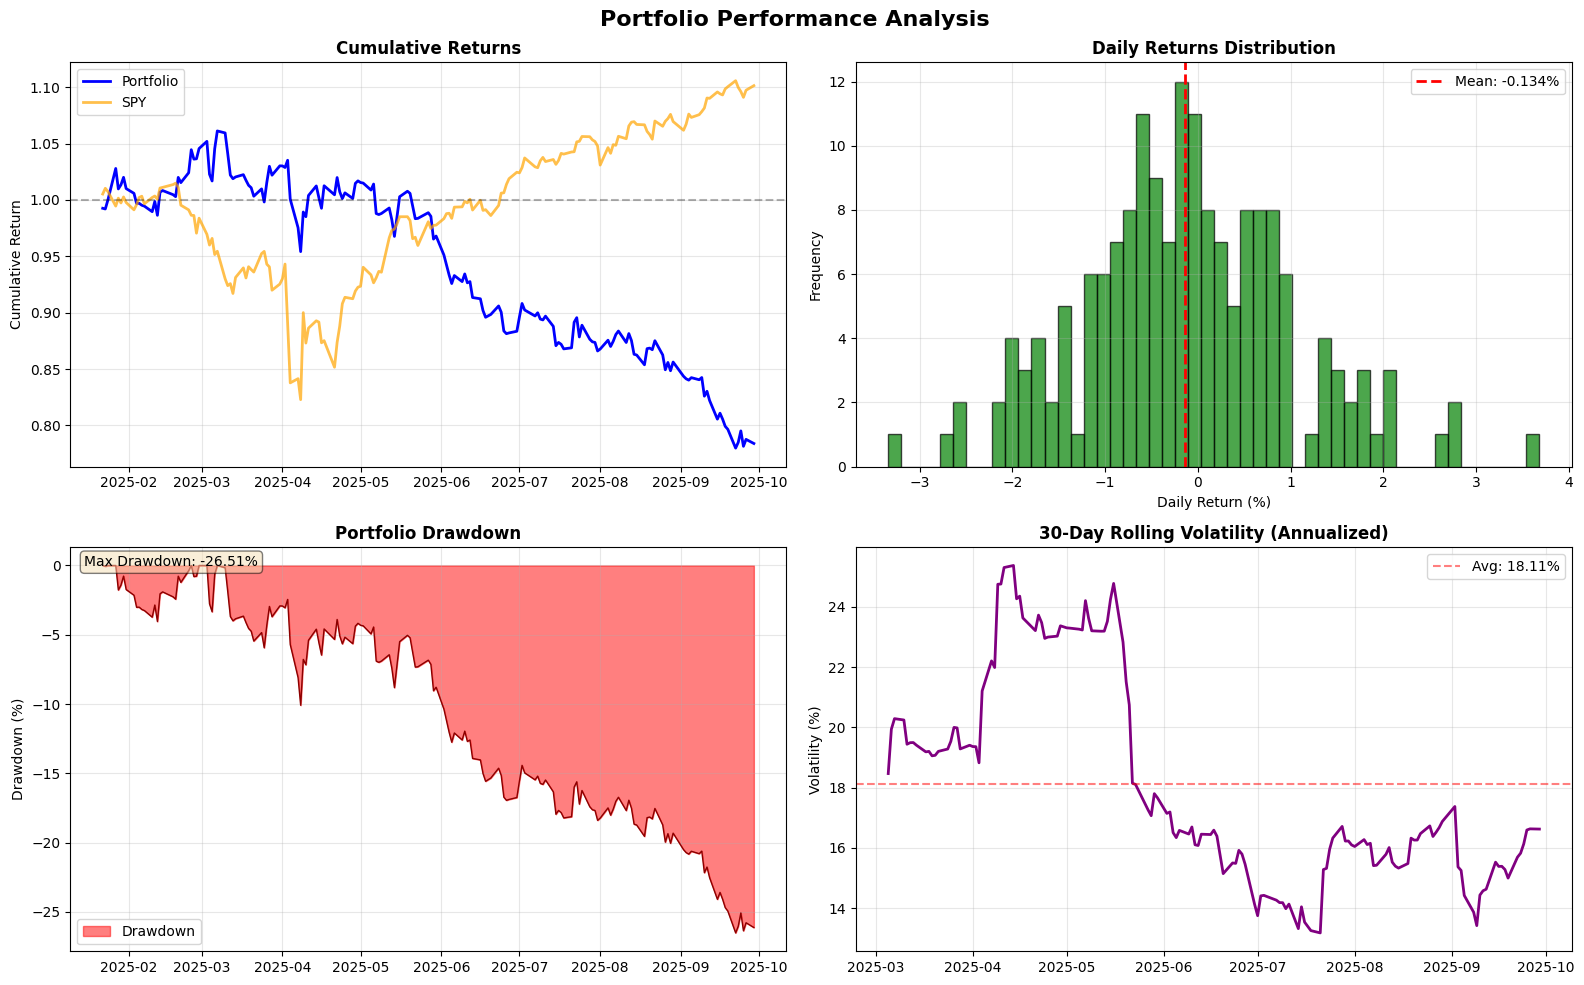

In [52]:
# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('Portfolio Performance Analysis', fontsize=16, fontweight='bold')

# 1. Cumulative returns - Portfolio vs SPY
ax1 = axes[0, 0]
portfolio_cumulative = (1 + portfolio_daily_returns).cumprod()
ax1.plot(portfolio_cumulative.index, portfolio_cumulative.values, 
         linewidth=2, color='blue', label='Portfolio')

if "SPY" in ticker_closes:
    spy_cumulative = (1 + spy_returns).cumprod()
    aligned_spy = spy_cumulative.reindex(portfolio_cumulative.index).ffill()
    ax1.plot(portfolio_cumulative.index, aligned_spy.values, 
             linewidth=2, color='orange', label='SPY', alpha=0.7)

ax1.set_title('Cumulative Returns', fontweight='bold')
ax1.set_ylabel('Cumulative Return')
ax1.grid(True, alpha=0.3)
ax1.legend()
ax1.axhline(y=1.0, color='black', linestyle='--', alpha=0.3)

# 2. Daily returns distribution
ax2 = axes[0, 1]
ax2.hist(portfolio_daily_returns.dropna() * 100, bins=50, alpha=0.7, 
         color='green', edgecolor='black')
ax2.axvline(portfolio_daily_returns.mean() * 100, color='red', 
            linestyle='--', linewidth=2, label=f'Mean: {portfolio_daily_returns.mean()*100:.3f}%')
ax2.set_title('Daily Returns Distribution', fontweight='bold')
ax2.set_xlabel('Daily Return (%)')
ax2.set_ylabel('Frequency')
ax2.grid(True, alpha=0.3)
ax2.legend()

# 3. Drawdown chart
ax3 = axes[1, 0]
running_max = portfolio_cumulative.cummax()
drawdown = (portfolio_cumulative / running_max - 1.0) * 100
ax3.fill_between(drawdown.index, drawdown.values, 0, 
                  alpha=0.5, color='red', label='Drawdown')
ax3.plot(drawdown.index, drawdown.values, linewidth=1, color='darkred')
ax3.set_title('Portfolio Drawdown', fontweight='bold')
ax3.set_ylabel('Drawdown (%)')
ax3.grid(True, alpha=0.3)
ax3.legend()
max_dd = drawdown.min()
ax3.text(0.02, 0.98, f'Max Drawdown: {max_dd:.2f}%', 
         transform=ax3.transAxes, verticalalignment='top',
         bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# 4. Rolling volatility (30-day)
ax4 = axes[1, 1]
rolling_vol = portfolio_daily_returns.rolling(window=30).std() * np.sqrt(252) * 100
ax4.plot(rolling_vol.index, rolling_vol.values, linewidth=2, color='purple')
ax4.axhline(y=annual_volatility * 100, color='red', linestyle='--', 
            alpha=0.5, label=f'Avg: {annual_volatility*100:.2f}%')
ax4.set_title('30-Day Rolling Volatility (Annualized)', fontweight='bold')
ax4.set_ylabel('Volatility (%)')
ax4.grid(True, alpha=0.3)
ax4.legend()

plt.tight_layout()
plt.show()


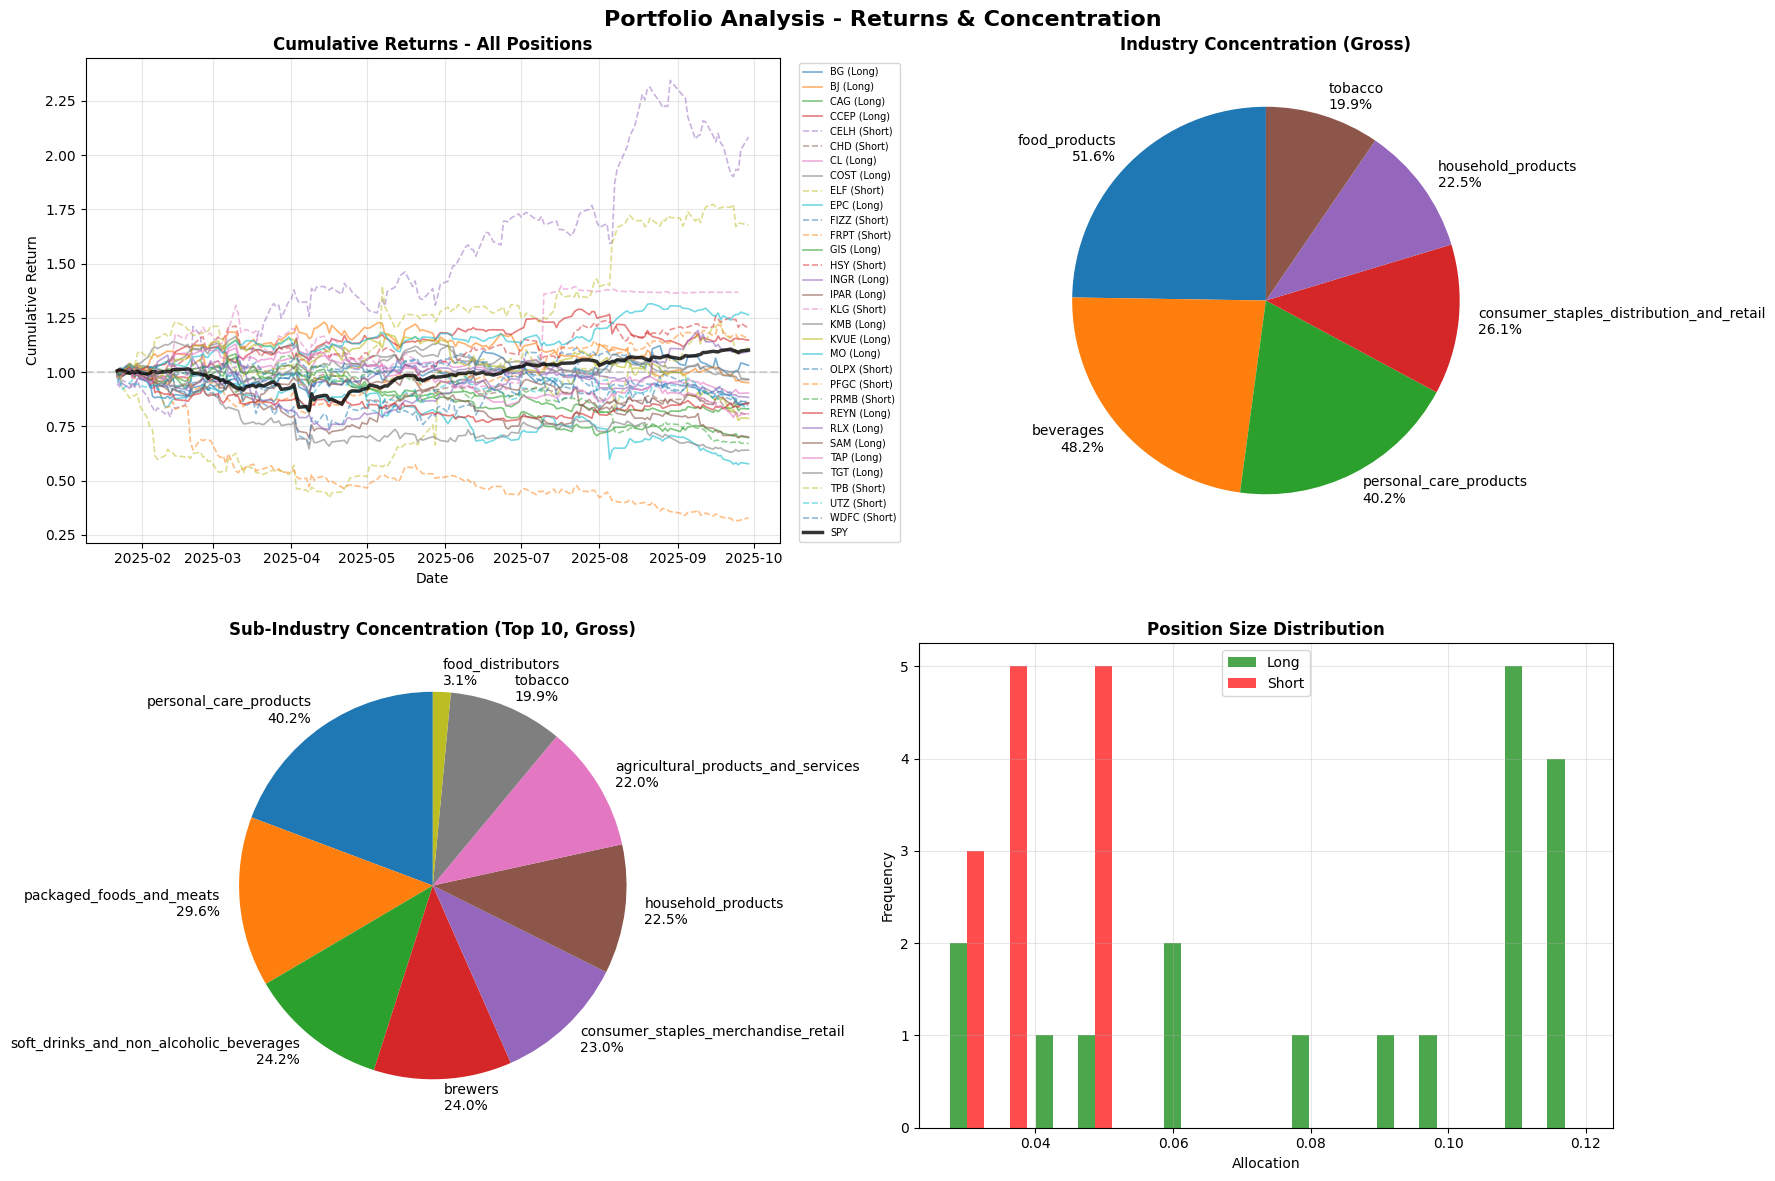

In [53]:
industry_data = {}
sub_industry_data = {}

with MarketSession() as session:
    for ticker in weights.keys():
        ticker_obj = session.query(Ticker).filter(Ticker.ticker == ticker.upper()).first()
        if ticker_obj:
            industry_data[ticker] = ticker_obj.industry
            sub_industry_data[ticker] = ticker_obj.sub_industry

# Calculate concentration by industry and sub-industry
industry_concentration = {}
sub_industry_concentration = {}

for ticker, allocation in weights.items():
    abs_allocation = abs(allocation)
    
    industry = industry_data.get(ticker, 'Unknown')
    if industry:
        industry_concentration[industry] = industry_concentration.get(industry, 0) + abs_allocation
    
    sub_industry = sub_industry_data.get(ticker, 'Unknown')
    if sub_industry:
        sub_industry_concentration[sub_industry] = sub_industry_concentration.get(sub_industry, 0) + abs_allocation

# Create figure with subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 12))
fig.suptitle('Portfolio Analysis - Returns & Concentration', fontsize=16, fontweight='bold')

# 1. Cumulative returns of all positions
ax1 = axes[0, 0]
for ticker in sorted(weights.keys()):
    if ticker in ticker_price_returns:
        cumulative_returns = (1 + ticker_price_returns[ticker]).cumprod()
        position_type = portfolio[ticker]['position']
        
        if position_type.lower() == 'short':
            ax1.plot(cumulative_returns.index, cumulative_returns.values, 
                    linestyle='--', alpha=0.5, linewidth=1.2, label=f"{ticker} (Short)")
        else:
            ax1.plot(cumulative_returns.index, cumulative_returns.values, 
                    alpha=0.6, linewidth=1.2, label=f"{ticker} (Long)")

if "SPY" in ticker_closes:
    spy_returns = ReturnsCalculator.daily_price_returns(ticker_closes["SPY"])
    spy_cumulative = (1 + spy_returns).cumprod()
    ax1.plot(spy_cumulative.index, spy_cumulative.values, 
            linewidth=2.5, color='black', label='SPY', alpha=0.8)

ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax1.set_title('Cumulative Returns - All Positions', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Return')
ax1.legend(bbox_to_anchor=(1.02, 1), loc='upper left', fontsize=7)
ax1.grid(True, alpha=0.3)

# 2. Industry concentration pie chart
ax2 = axes[0, 1]
if industry_concentration:
    labels = [f"{k}\n{v:.1%}" for k, v in sorted(industry_concentration.items(), key=lambda x: x[1], reverse=True)]
    sizes = [v for k, v in sorted(industry_concentration.items(), key=lambda x: x[1], reverse=True)]
    ax2.pie(sizes, labels=labels, autopct='', startangle=90)
    ax2.set_title('Industry Concentration (Gross)', fontweight='bold')

# 3. Sub-industry concentration pie chart
ax3 = axes[1, 0]
if sub_industry_concentration:
    # Limit to top 10 for readability
    sorted_sub = sorted(sub_industry_concentration.items(), key=lambda x: x[1], reverse=True)[:10]
    labels = [f"{k}\n{v:.1%}" for k, v in sorted_sub]
    sizes = [v for k, v in sorted_sub]
    ax3.pie(sizes, labels=labels, autopct='', startangle=90)
    ax3.set_title('Sub-Industry Concentration (Top 10, Gross)', fontweight='bold')

# 4. Position size distribution
ax4 = axes[1, 1]
long_weights = [v for v in weights.values() if v > 0]
short_weights = [abs(v) for v in weights.values() if v < 0]
ax4.hist([long_weights, short_weights], bins=15, label=['Long', 'Short'], alpha=0.7, color=['green', 'red'])
ax4.set_title('Position Size Distribution', fontweight='bold')
ax4.set_xlabel('Allocation')
ax4.set_ylabel('Frequency')
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


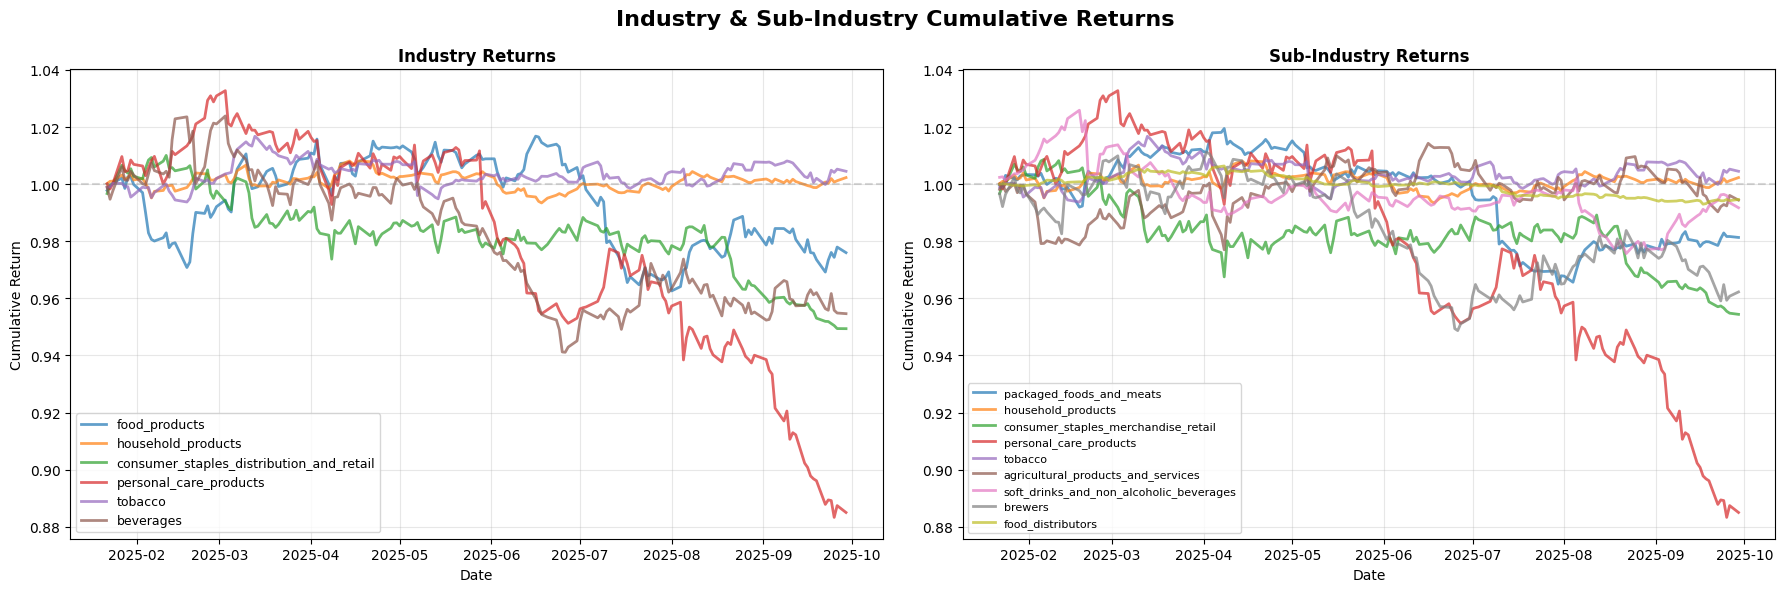

In [54]:
# Calculate industry and sub-industry level returns
# Group tickers by industry
industry_groups = {}
for ticker, allocation in weights.items():
    if ticker in ticker_price_returns:
        industry = industry_data.get(ticker)
        if industry:
            if industry not in industry_groups:
                industry_groups[industry] = {}
            industry_groups[industry][ticker] = allocation

# Group tickers by sub-industry
sub_industry_groups = {}
for ticker, allocation in weights.items():
    if ticker in ticker_price_returns:
        sub_industry = sub_industry_data.get(ticker)
        if sub_industry:
            if sub_industry not in sub_industry_groups:
                sub_industry_groups[sub_industry] = {}
            sub_industry_groups[sub_industry][ticker] = allocation

# Calculate industry-level returns
industry_returns = {}
for industry, tickers_weights in industry_groups.items():
    industry_ticker_returns = {t: ticker_price_returns[t] for t in tickers_weights.keys()}
    industry_daily_returns = PortfolioReturnsCalculator.weighted_daily_returns(
        industry_ticker_returns,
        tickers_weights,
        dropna=False
    )
    industry_returns[industry] = industry_daily_returns

# Calculate sub-industry-level returns
sub_industry_returns = {}
for sub_industry, tickers_weights in sub_industry_groups.items():
    sub_industry_ticker_returns = {t: ticker_price_returns[t] for t in tickers_weights.keys()}
    sub_industry_daily_returns = PortfolioReturnsCalculator.weighted_daily_returns(
        sub_industry_ticker_returns,
        tickers_weights,
        dropna=False
    )
    sub_industry_returns[sub_industry] = sub_industry_daily_returns

# Create two graphs
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
fig.suptitle('Industry & Sub-Industry Cumulative Returns', fontsize=16, fontweight='bold')

# 1. Industry returns
ax1 = axes[0]
for industry, returns in industry_returns.items():
    cumulative_returns = (1 + returns).cumprod()
    ax1.plot(cumulative_returns.index, cumulative_returns.values, 
            linewidth=2, alpha=0.7, label=industry)

ax1.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax1.set_title('Industry Returns', fontweight='bold')
ax1.set_xlabel('Date')
ax1.set_ylabel('Cumulative Return')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)

# 2. Sub-industry returns
ax2 = axes[1]
for sub_industry, returns in sub_industry_returns.items():
    cumulative_returns = (1 + returns).cumprod()
    ax2.plot(cumulative_returns.index, cumulative_returns.values, 
            linewidth=2, alpha=0.7, label=sub_industry)

ax2.axhline(y=1.0, color='gray', linestyle='--', alpha=0.3)
ax2.set_title('Sub-Industry Returns', fontweight='bold')
ax2.set_xlabel('Date')
ax2.set_ylabel('Cumulative Return')
ax2.legend(loc='best', fontsize=8)
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()
